# Practice 1: PyTorch FashionMNIST Classification

## MLP vs DiagnosticCNN — Comparison

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load PyTorch, src modules, detect device | — |
| 2 | Persistent Split & Loaders | 70k split → 50k/6k/14k, plain + aug loaders | `src/data_utils.py` |
| 3 | Explore Dataset | Shape, class distribution, pixel stats | `src/vis_utils.py` |
| 4 | Define Models | MLP (215→470→10) vs DiagnosticCNN | — |
| 5 | Train Both Models | MLP: 10ep plain; CNN: 35ep augmented | `src/train_utils.py` |
| 6 | Compare: Loss Curves | Separate plots for MLP and CNN | `src/vis_utils.py` |
| 7 | Compare: Confusion Matrices | Per-class TPR/FPR/Precision + heatmaps | `src/eval_utils.py` |
| 8 | Compare: ROC Curves | Per-class ROC curves + AUC | `src/eval_utils.py` + `src/vis_utils.py` |
| 9 | Compare: PR Curves | Per-class PR curves + AP | `src/eval_utils.py` + `src/vis_utils.py` |
| 10 | Summary Table | Accuracy / ROC-AUC / PR-AUC / Params | `src/eval_utils.py` |
| 11 | Save Models | Save .pth weights | `src/model_utils.py` |
| 12 | Display Predictions | Predicted vs actual images | `src/vis_utils.py` |

---

## 1. Import Libraries

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import copy

from src.data_utils import create_full_split, load_subsets, get_augmented_transforms
from src.vis_utils import explore_dataset, plot_losses, plot_confusion_matrix
from src.vis_utils import plot_roc_curves, plot_pr_curves, plot_predictions
from src.model_utils import save_model
from src.eval_utils import evaluate_detailed, get_all_probas_and_labels
from src.eval_utils import compute_roc_auc_scores, compute_pr_auc_scores, print_comparison_table

print(f"PyTorch version: {torch.__version__}")
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.8.0
Using device: mps


## 2. Persistent Split & DataLoaders

Full 70k FashionMNIST merged → shuffled → split **train (50k) / val (6k) / test (14k)**.
Indices saved to `splits/*.json` — deterministic across runs.

MLP trains on plain data (no augmentation). CNN trains on augmented data.

In [2]:
create_full_split()

train_loader, val_loader, test_loader, class_names = load_subsets(batch_size=64)
train_loader_cnn, val_loader_cnn, _, _ = load_subsets(
    batch_size=64, train_transform=get_augmented_transforms())

print(f'Train: {len(train_loader.dataset)}  Val: {len(val_loader.dataset)}  Test: {len(test_loader.dataset)}')
print(f'Classes: {class_names}')

[data_utils] All split files exist — loading from ../splits
Train: 50000  Val: 6000  Test: 14000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 3. Explore Dataset

Print basic info (classes, shape), show 10 clean sample images, class distribution bar chart, and pixel intensity histogram.

Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Num samples: 50000
Image shape: torch.Size([1, 28, 28])


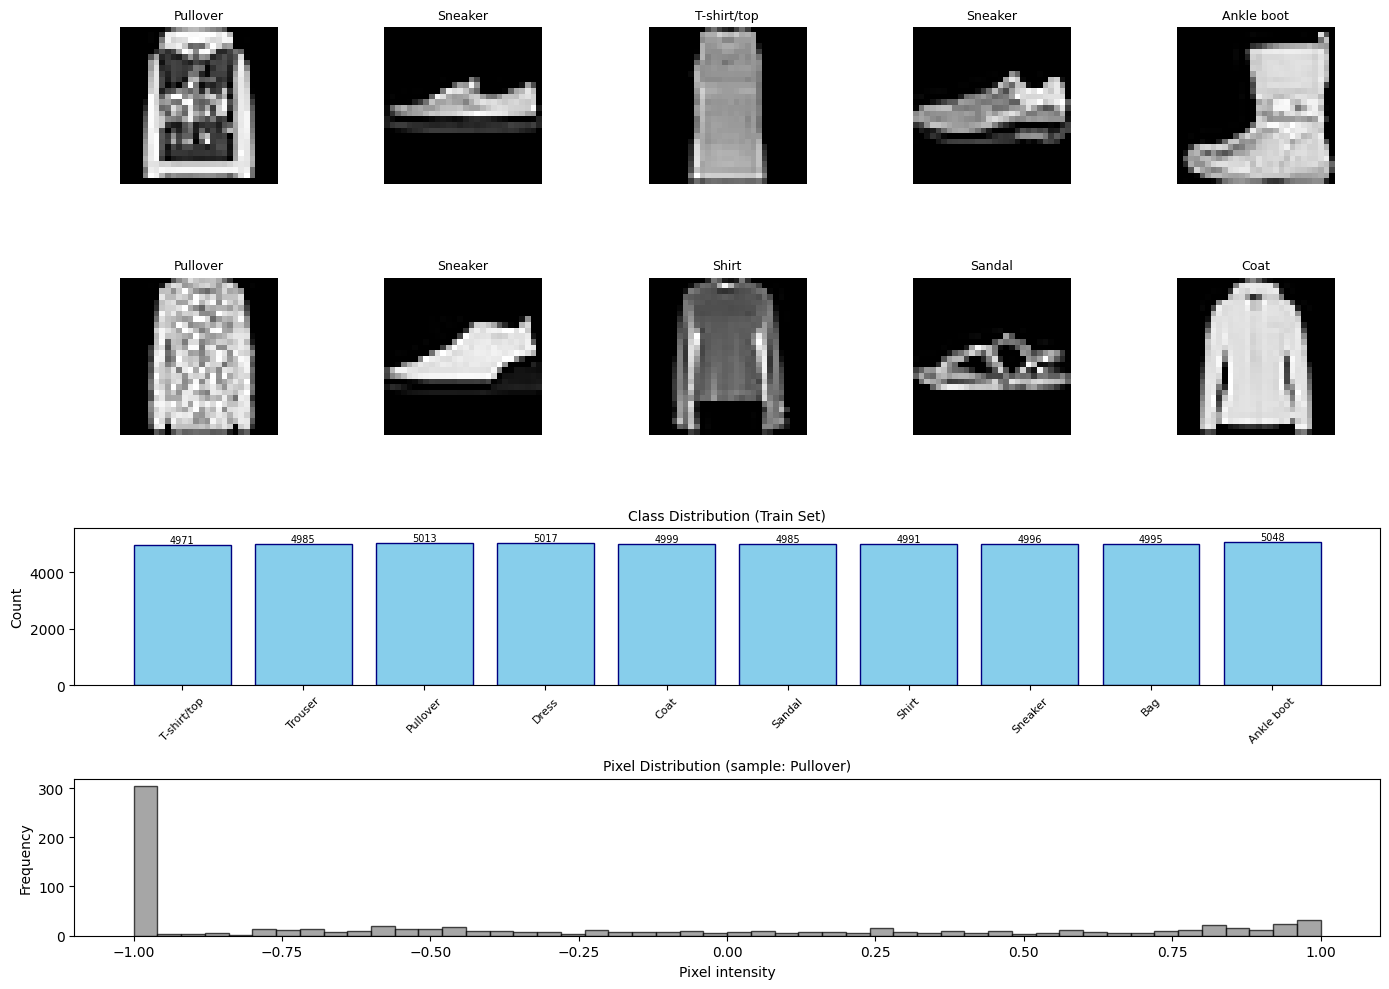

Image tensor shape: torch.Size([1, 28, 28])
Image tensor dtype: torch.float32
Pixel value range: [-1.0000, 1.0000]
Mean pixel value: -0.3216
Std pixel value: 0.7191


In [3]:
explore_dataset(train_loader.dataset, class_names)

## 4. Define Models

**MLP:** `784 -> 215 -> 470 -> 10`, GELU, Dropout(0.15). HP from Optuna.

**DiagnosticCNN:** 3 conv blocks (32→64→128), BatchNorm, ReLU, GAP, Dropout(0.454). HP from Optuna.

In [4]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_1=215, hidden_2=470, num_classes=10, dropout=0.15):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, num_classes)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = self.act(self.fc1(x))
        x = self.dropout(x)
        x = self.act(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


class DiagnosticCNN(nn.Module):
    def __init__(self, dropout=0.454):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.net(x)


model_mlp = MLP().to(device)
model_cnn = DiagnosticCNN().to(device)

mlp_params = sum(p.numel() for p in model_mlp.parameters())
cnn_params = sum(p.numel() for p in model_cnn.parameters())
print(f'MLP params: {mlp_params:,}')
print(f'CNN params: {cnn_params:,}')

MLP params: 275,005
CNN params: 140,778


## 5. Train Both Models

MLP: plain data, `AdamW(lr=0.002, wd=2e-6)`, 10 epochs, `CosineAnnealingLR`, early stop patience=5.

CNN: augmented data, `AdamW(lr=0.003322, wd=1.39e-5)`, 35 epochs, early stop patience=5.

In [5]:
criterion = nn.CrossEntropyLoss()

print('--- Training MLP (plain data) ---')
optimizer_mlp = optim.AdamW(model_mlp.parameters(), lr=0.002, weight_decay=2e-6)
scheduler_mlp = CosineAnnealingLR(optimizer_mlp, T_max=10)
train_losses_mlp = []
val_losses_mlp = []
best_val_loss = float('inf')
best_mlp_state = None
patience = 5
wait = 0
model_mlp.train()
for epoch in range(10):
    from src.train_utils import train_one_epoch
    train_loss = train_one_epoch(model_mlp, train_loader, criterion, optimizer_mlp, device)
    train_losses_mlp.append(train_loss)
    scheduler_mlp.step()
    model_mlp.eval()
    vloss = 0.0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            vloss += criterion(model_mlp(img), lbl).item()
    val_losses_mlp.append(vloss / len(val_loader))
    model_mlp.train()
    if val_losses_mlp[-1] < best_val_loss:
        best_val_loss = val_losses_mlp[-1]
        best_mlp_state = copy.deepcopy(model_mlp.state_dict())
        wait = 0
    else:
        wait += 1
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/10]  Train: {train_loss:.4f}  Val: {val_losses_mlp[-1]:.4f}')
    if wait >= patience:
        print(f'Early stop at epoch {epoch+1}')
        break
model_mlp.load_state_dict(best_mlp_state)
print(f'Restored best MLP checkpoint (val_loss={best_val_loss:.4f})')

import os
os.makedirs('../outputs/practice_1/metrics', exist_ok=True)
for name, losses in [('train_losses_MLP.txt', train_losses_mlp), ('val_losses_MLP.txt', val_losses_mlp)]:
    with open(f'../outputs/practice_1/metrics/{name}', 'w') as f:
        for l in losses:
            f.write(f'{l}\n')

print('\n--- Training DiagnosticCNN (augmented data) ---')
EPOCHS_CNN = 35
optimizer_cnn = optim.AdamW(model_cnn.parameters(), lr=0.003322, weight_decay=1.39e-5)
scheduler_cnn = CosineAnnealingLR(optimizer_cnn, T_max=EPOCHS_CNN)
train_losses_cnn = []
val_losses_cnn = []
best_val_loss_cnn = float('inf')
best_cnn_state = None
wait_cnn = 0
model_cnn.train()
for epoch in range(EPOCHS_CNN):
    from src.train_utils import train_one_epoch
    train_loss = train_one_epoch(model_cnn, train_loader_cnn, criterion, optimizer_cnn, device)
    train_losses_cnn.append(train_loss)
    scheduler_cnn.step()
    model_cnn.eval()
    vloss = 0.0
    with torch.no_grad():
        for img, lbl in val_loader_cnn:
            img, lbl = img.to(device), lbl.to(device)
            vloss += criterion(model_cnn(img), lbl).item()
    val_losses_cnn.append(vloss / len(val_loader_cnn))
    model_cnn.train()
    if val_losses_cnn[-1] < best_val_loss_cnn:
        best_val_loss_cnn = val_losses_cnn[-1]
        best_cnn_state = copy.deepcopy(model_cnn.state_dict())
        wait_cnn = 0
    else:
        wait_cnn += 1
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS_CNN}]  Train: {train_loss:.4f}  Val: {val_losses_cnn[-1]:.4f}')
    if wait_cnn >= patience:
        print(f'Early stop at epoch {epoch+1}')
        break
model_cnn.load_state_dict(best_cnn_state)
print(f'Restored best CNN checkpoint (val_loss={best_val_loss_cnn:.4f})')
for name, losses in [('train_losses_CNN.txt', train_losses_cnn), ('val_losses_CNN.txt', val_losses_cnn)]:
    with open(f'../outputs/practice_1/metrics/{name}', 'w') as f:
        for l in losses:
            f.write(f'{l}\n')

--- Training MLP (plain data) ---
Epoch [1/10]  Train: 0.5312  Val: 0.4567
Epoch [5/10]  Train: 0.3245  Val: 0.3338
Epoch [10/10]  Train: 0.2147  Val: 0.2986
Restored best MLP checkpoint (val_loss=0.2986)

--- Training DiagnosticCNN (augmented data) ---
Epoch [1/35]  Train: 0.7300  Val: 0.5030
Epoch [5/35]  Train: 0.3982  Val: 0.3687
Epoch [10/35]  Train: 0.3346  Val: 0.3053
Epoch [15/35]  Train: 0.3026  Val: 0.2810
Epoch [20/35]  Train: 0.2743  Val: 0.2664
Epoch [25/35]  Train: 0.2538  Val: 0.2477
Epoch [30/35]  Train: 0.2397  Val: 0.2449
Epoch [35/35]  Train: 0.2341  Val: 0.2428
Restored best CNN checkpoint (val_loss=0.2325)


## 6. Compare: Loss Curves

Separate plots for MLP and CNN. Solid = training loss, dashed = validation loss.

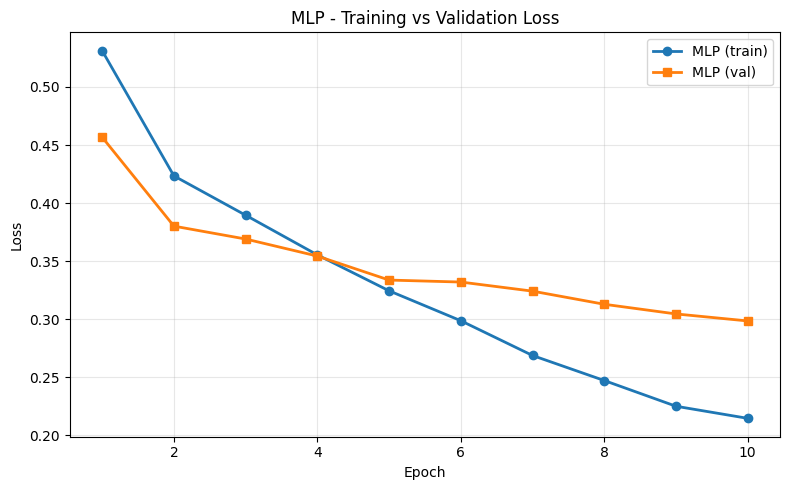

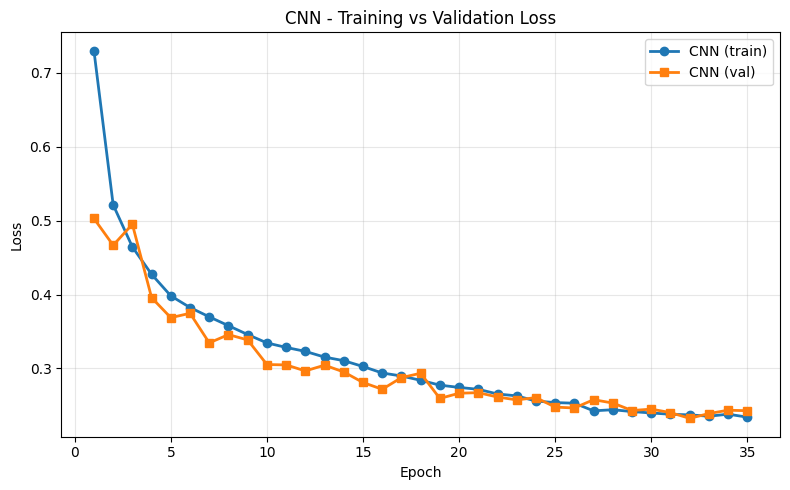

In [6]:
plot_losses({'MLP (train)': train_losses_mlp, 'MLP (val)': val_losses_mlp},
           title='MLP - Training vs Validation Loss',
           save_path='../outputs/practice_1/plots/mlp_loss.png')
plot_losses({'CNN (train)': train_losses_cnn, 'CNN (val)': val_losses_cnn},
           title='CNN - Training vs Validation Loss',
           save_path='../outputs/practice_1/plots/cnn_loss.png')

## 7. Compare: Confusion Matrices

  Test Accuracy: 89.62%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8544     0.0166     0.8526
  Trouser             0.9808     0.0009     0.9921
  Pullover            0.8397     0.0190     0.8283
  Dress               0.9073     0.0117     0.8944
  Coat                0.8556     0.0219     0.8074
  Sandal              0.9503     0.0033     0.9704
  Shirt               0.7022     0.0265     0.7515
  Sneaker             0.9644     0.0087     0.9248
  Bag                 0.9649     0.0030     0.9731
  Ankle boot          0.9437     0.0036     0.9659


  Test Accuracy: 93.04%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8940     0.0139     0.8785
  Trouser             0.9922     0.0010     0.9915
  Pullover            0.9050     0.0109     0.9011
  Dress               0.9030     0.0064     0.9390
  Coat                0.9278     0.0

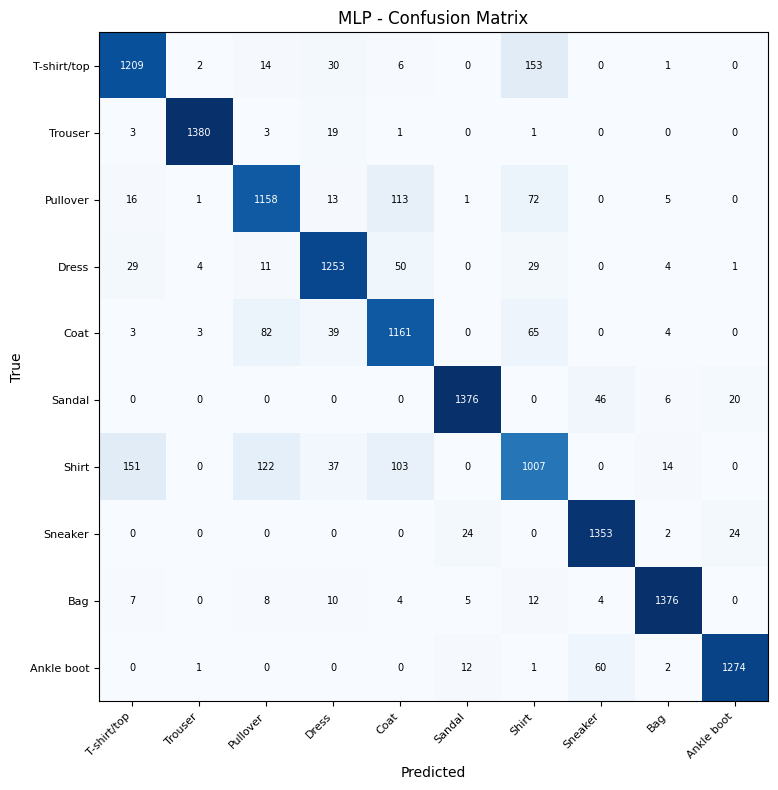

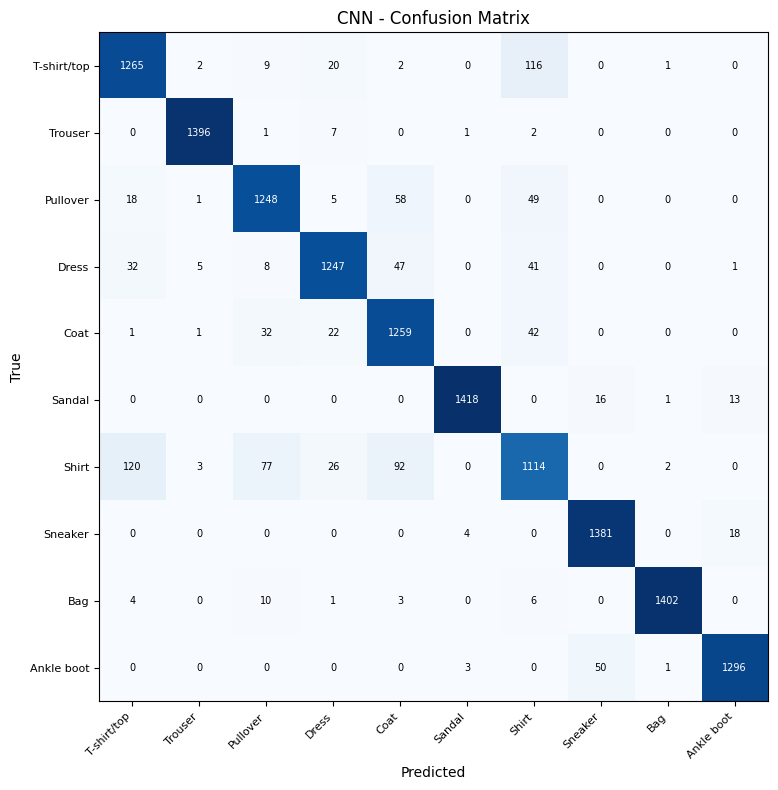

In [7]:
acc_mlp, cm_mlp, _ = evaluate_detailed(model_mlp, test_loader, device, class_names)
print('\n')
acc_cnn, cm_cnn, _ = evaluate_detailed(model_cnn, test_loader, device, class_names)

plot_confusion_matrix(cm_mlp, class_names, title='MLP - Confusion Matrix',
                      save_path='../outputs/practice_1/plots/confusion_matrix_mlp.png')
plot_confusion_matrix(cm_cnn, class_names, title='CNN - Confusion Matrix',
                      save_path='../outputs/practice_1/plots/confusion_matrix_cnn.png')

## 8. Compare: ROC Curves

MLP macro ROC-AUC: 0.9930
CNN macro ROC-AUC: 0.9965


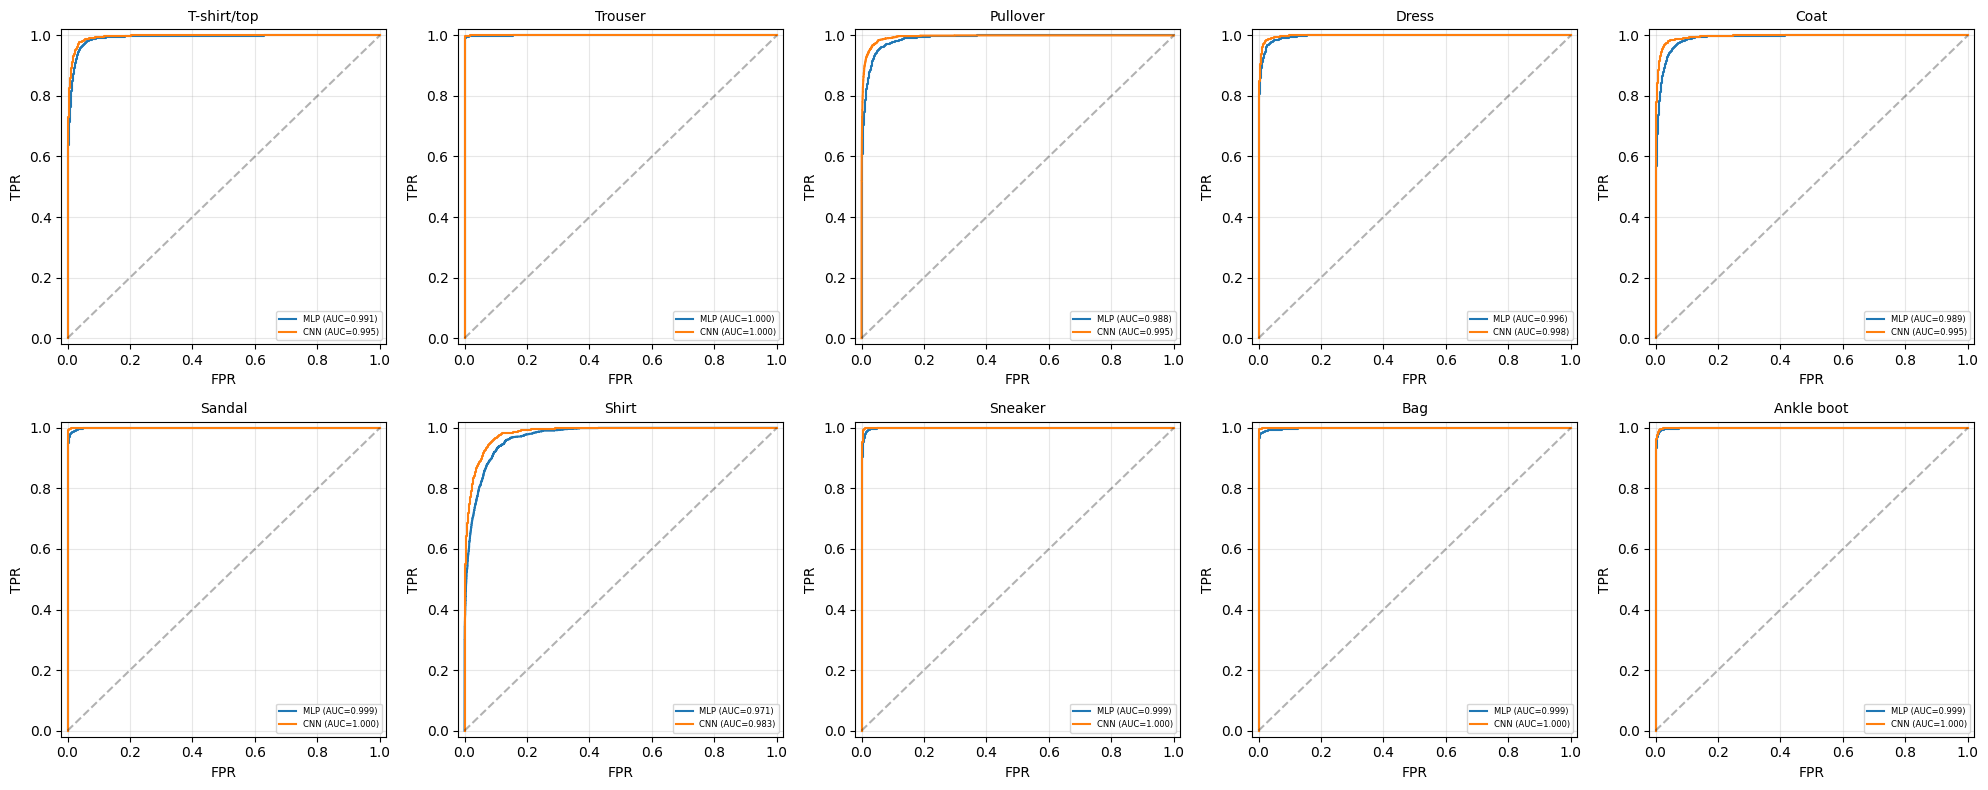

In [8]:
probas_mlp, labels = get_all_probas_and_labels(model_mlp, test_loader, device, 10)
probas_cnn, _ = get_all_probas_and_labels(model_cnn, test_loader, device, 10)
roc_mlp = compute_roc_auc_scores(probas_mlp, labels)
roc_cnn = compute_roc_auc_scores(probas_cnn, labels)
print(f'MLP macro ROC-AUC: {roc_mlp["macro"]:.4f}')
print(f'CNN macro ROC-AUC: {roc_cnn["macro"]:.4f}')
plot_roc_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 9. Compare: PR Curves

MLP macro PR-AUC (AP): 0.9525
CNN macro PR-AUC (AP): 0.9752


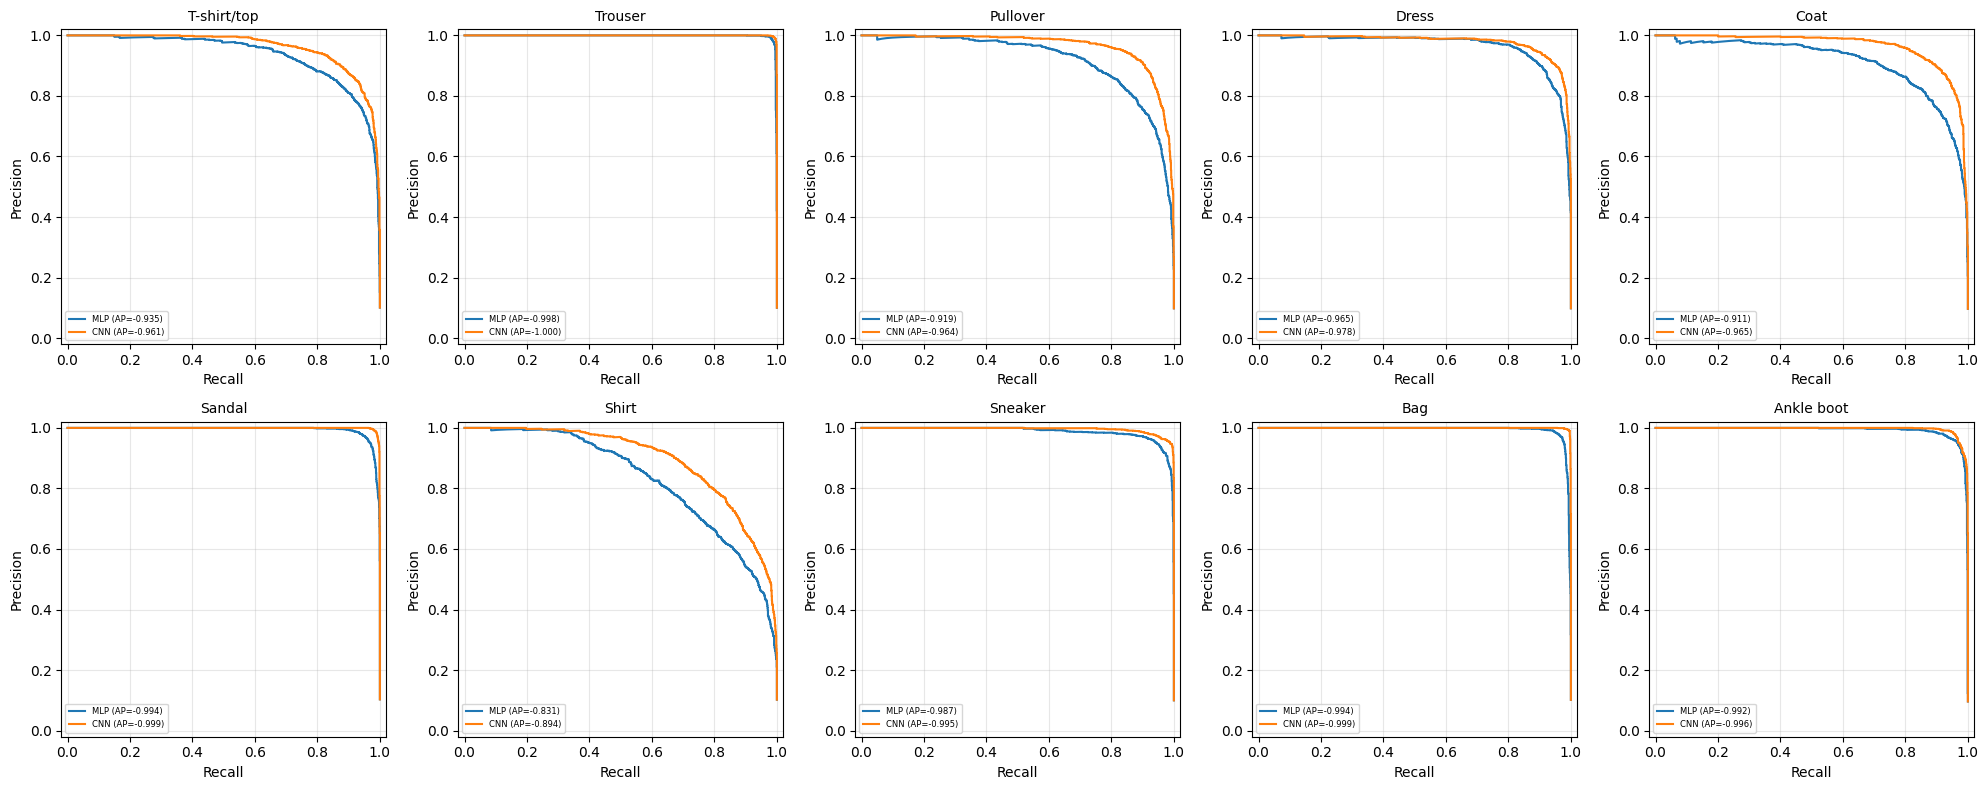

In [9]:
pr_mlp = compute_pr_auc_scores(probas_mlp, labels)
pr_cnn = compute_pr_auc_scores(probas_cnn, labels)
print(f'MLP macro PR-AUC (AP): {pr_mlp["macro"]:.4f}')
print(f'CNN macro PR-AUC (AP): {pr_cnn["macro"]:.4f}')
plot_pr_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 10. Summary Table

In [10]:
print_comparison_table(acc_mlp, acc_cnn, roc_mlp, roc_cnn, pr_mlp, pr_cnn,
                       mlp_params, cnn_params, class_names)

Metric                             MLP          CNN         Diff
---------------------------------------------------------------------------
Test Accuracy (%)               89.62       93.04       +3.42
Macro ROC-AUC                  0.9930      0.9965     +0.0035
Macro PR-AUC (AP)              0.9525      0.9752     +0.0227
Parameters                    275,005     140,778    -134,227

Per-class ROC-AUC                  MLP          CNN
--------------------------------------------------
T-shirt/top                    0.9909      0.9949
Trouser                        0.9997      1.0000
Pullover                       0.9884      0.9951
Dress                          0.9956      0.9975
Coat                           0.9890      0.9953
Sandal                         0.9992      0.9999
Shirt                          0.9714      0.9835
Sneaker                        0.9985      0.9995
Bag                            0.9989      0.9999
Ankle boot                     0.9986      0.9996

Per-cl

## 11. Save Models

In [11]:
save_model(model_mlp, '../outputs/practice_1/model/mlp.pth')
save_model(model_cnn, '../outputs/practice_1/model/cnn.pth')

Model saved to ../outputs/practice_1/model/mlp.pth
Model saved to ../outputs/practice_1/model/cnn.pth


## 12. Display Predicted vs Actual Images

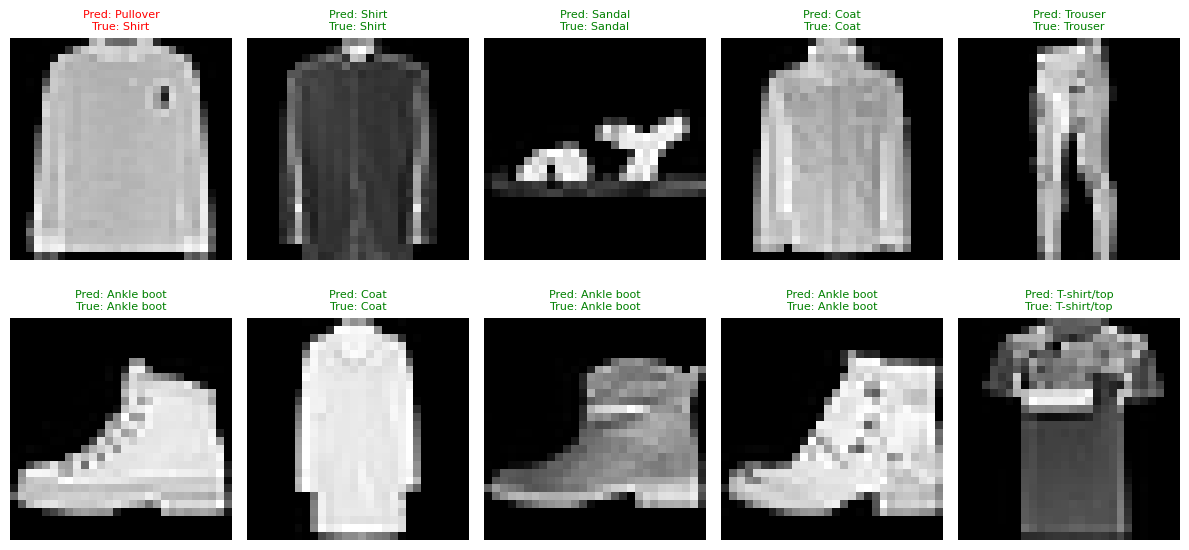

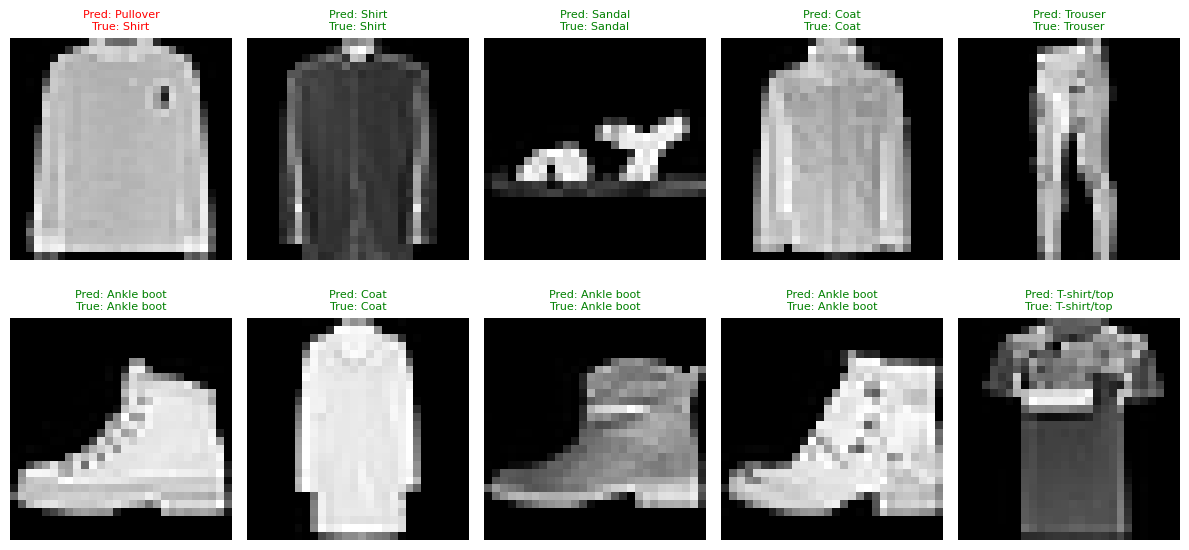

In [12]:
plot_predictions(model_mlp, test_loader, class_names, device,
               '../outputs/practice_1/plots/predictions_mlp.png')
plot_predictions(model_cnn, test_loader, class_names, device,
               '../outputs/practice_1/plots/predictions_cnn.png')